# Unit 2 | NLP 03 — Text Classification & Model Comparison

This notebook builds and compares text classification pipelines across every vectorization approach:

1. **Feature preparation** — CountVec, TF-IDF, and Sentence Embeddings
2. **Systematic model grid** — every classifier × every representation, ranked by Macro F1
3. **Per-category breakdown** — classification report side-by-side for best classical vs. best embedding
4. **Grid Search** — k-fold cross-validation for TF-IDF + Logistic Regression
5. **Feature importance** — RF feature importance, LR coefficients, and SHAP beeswarm

**Dataset:** sklearn 20 Newsgroups

## Setup

Standard ML stack: **scikit-learn** for classical models, **sentence-transformers** for dense embeddings, and **SHAP** for explainability. `warnings.filterwarnings('ignore')` suppresses verbose convergence logs that would otherwise clutter the model-sweep output.

In [38]:
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.base import clone
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sentence_transformers import SentenceTransformer
import shap

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

In [39]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
CATEGORIES   = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'talk.religion.misc']
RANDOM_STATE = 42
MAX_FEATURES = 10000
EMB_MODEL    = 'all-MiniLM-L6-v2'
# ─────────────────────────────────────────────────────────────────────────────

### Load Data

`fetch_20newsgroups` pulls a subset of the classic 20 Newsgroups corpus — four categories that span clearly different domains (computer graphics, hockey, space science, religion) so class separation is learnable but not trivial. The `remove=('headers', 'footers', 'quotes')` flag strips metadata and quoted replies, forcing the model to classify on actual message content rather than authoring artifacts.

In [40]:
train = fetch_20newsgroups(
    subset='train', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'), random_state=RANDOM_STATE
)
test = fetch_20newsgroups(
    subset='test', categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'), random_state=RANDOM_STATE
)

print(f"Train: {len(train.data):,} docs   Test: {len(test.data):,} docs")
print(f"Classes: {train.target_names}")

Train: 2,154 docs   Test: 1,433 docs
Classes: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.religion.misc']


## Section 1: Prepare All Feature Sets

We compute all representations up front so that model timing reflects only fit+predict, not vectorization.

- **CountVec / TF-IDF**: sparse term matrices (`MAX_FEATURES=10000`)
- **tfidf_shap**: smaller TF-IDF at 5000 features used for SHAP (densifying 10k features requires ~172 MB)
- **Embeddings**: dense 384-dim vectors from `all-MiniLM-L6-v2` (download once, cached after)

The key rule: all vectorizers are **fit on training data only**, then transform both splits.

In [41]:
# ── Classical vectorizers ────────────────────────────────────────────────────
print('Fitting CountVectorizer...', end=' ', flush=True)
cv = CountVectorizer(max_features=MAX_FEATURES, stop_words='english')
X_train_cv  = cv.fit_transform(train.data)
X_test_cv   = cv.transform(test.data)
print('done')

print('Fitting TfidfVectorizer...', end=' ', flush=True)
tfidf = TfidfVectorizer(max_features=MAX_FEATURES, stop_words='english', sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(train.data)
X_test_tfidf  = tfidf.transform(test.data)
print('done')

# Smaller TF-IDF for SHAP (5k features keeps dense arrays manageable)
print('Fitting TfidfVectorizer (SHAP)...', end=' ', flush=True)
tfidf_shap = TfidfVectorizer(max_features=5000, stop_words='english', sublinear_tf=True)
X_train_tfidf_shap = tfidf_shap.fit_transform(train.data)
X_test_tfidf_shap  = tfidf_shap.transform(test.data)
print('done')

# ── Sentence embeddings ──────────────────────────────────────────────────────
print(f'Encoding with {EMB_MODEL}...')
emb_model   = SentenceTransformer(EMB_MODEL)
X_train_emb = emb_model.encode(train.data, show_progress_bar=True, batch_size=64)
X_test_emb  = emb_model.encode(test.data,  show_progress_bar=True, batch_size=64)
print(f'Embeddings: train={X_train_emb.shape}  test={X_test_emb.shape}')

Fitting CountVectorizer... done
Fitting TfidfVectorizer... done
Fitting TfidfVectorizer (SHAP)... done
Encoding with all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Embeddings: train=(2154, 384)  test=(1433, 384)


## Section 2: Systematic Model Grid — All Classifiers × All Representations

We evaluate every valid combination of representation and classifier:

| Representation | Classifiers |
|---|---|
| CountVec | NaiveBayes, LogisticReg, LinearSVC, RandomForest, SGD |
| TF-IDF | NaiveBayes, LogisticReg, LinearSVC, RandomForest, SGD |
| Embeddings | LogisticReg, LinearSVC, RandomForest, SGD |

**Note:** MultinomialNB is excluded for embeddings — it requires non-negative features.
Each fit is timed (fit + predict seconds) for a direct speed comparison.

In [42]:
def evaluate(name, clf, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    clf.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_te)
    t_pred = time.time() - t0

    return {
        'Model'       : name,
        'Accuracy'    : round(accuracy_score(y_te, y_pred), 4),
        'Macro F1'    : round(f1_score(y_te, y_pred, average='macro'), 4),
        'Fit (s)'     : round(t_fit, 2),
        'Predict (s)' : round(t_pred, 3),
        '_preds'      : y_pred,
        '_clf'        : clf,
        'Representation': '',  # filled below
        'Classifier'    : '',
    }

feature_sets = {
    'CountVec'  : (X_train_cv,    X_test_cv),
    'TF-IDF'    : (X_train_tfidf, X_test_tfidf),
    'Embeddings': (X_train_emb,   X_test_emb),
}

classifier_configs = [
    ('NaiveBayes',          True,  MultinomialNB()),
    ('LogisticReg(C=1)',    False, LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    ('LinearSVC(C=1)',      False, LinearSVC(C=1.0, max_iter=2000, random_state=RANDOM_STATE)),
    ('RandomForest(n=200)', False, RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ('SGD(log_loss)',       False, SGDClassifier(loss='log_loss', learning_rate='optimal',
                                                 max_iter=100, random_state=RANDOM_STATE, n_jobs=-1)),
]

rows = []
for rep_name, (X_tr, X_te) in feature_sets.items():
    for clf_label, nb_only, clf_proto in classifier_configs:
        if nb_only and rep_name == 'Embeddings':
            continue   # MultinomialNB needs non-negative features
        name = f'{rep_name} + {clf_label}'
        print(f'  {name}...', end=' ', flush=True)
        row = evaluate(name, clone(clf_proto), X_tr, train.target, X_te, test.target)
        row['Representation'] = rep_name
        row['Classifier']     = clf_label
        print(f"Acc={row['Accuracy']:.4f}  F1={row['Macro F1']:.4f}")
        rows.append(row)

results_df = (
    pd.DataFrame(rows)
    .drop(columns=['_preds', '_clf'])
    .sort_values('Macro F1', ascending=False)
    .reset_index(drop=True)
)
results_df

  CountVec + NaiveBayes... Acc=0.8828  F1=0.8778
  CountVec + LogisticReg(C=1)... Acc=0.8542  F1=0.8475
  CountVec + LinearSVC(C=1)... Acc=0.8214  F1=0.8143
  CountVec + RandomForest(n=200)... Acc=0.8430  F1=0.8351
  CountVec + SGD(log_loss)... Acc=0.8332  F1=0.8285
  TF-IDF + NaiveBayes... Acc=0.8870  F1=0.8799
  TF-IDF + LogisticReg(C=1)... Acc=0.8890  F1=0.8848
  TF-IDF + LinearSVC(C=1)... Acc=0.8925  F1=0.8903
  TF-IDF + RandomForest(n=200)... Acc=0.8493  F1=0.8413
  TF-IDF + SGD(log_loss)... Acc=0.8967  F1=0.8930
  Embeddings + LogisticReg(C=1)... Acc=0.8981  F1=0.8951
  Embeddings + LinearSVC(C=1)... Acc=0.8856  F1=0.8807
  Embeddings + RandomForest(n=200)... Acc=0.8800  F1=0.8755
  Embeddings + SGD(log_loss)... Acc=0.8925  F1=0.8902


,Model,Accuracy,Macro F1,Fit (s),Predict (s),Representation,Classifier
0,Embeddings + LogisticReg(C=1),0.8981,0.8951,0.02,0.002,Embeddings,LogisticReg(C=1)
1,TF-IDF + SGD(log_loss),0.8967,0.8930,0.02,0.001,TF-IDF,SGD(log_loss)
2,TF-IDF + LinearSVC(C=1),0.8925,0.8903,0.03,0.001,TF-IDF,LinearSVC(C=1)
3,Embeddings + SGD(log_loss),0.8925,0.8902,0.06,0.001,Embeddings,SGD(log_loss)
4,TF-IDF + LogisticReg(C=1),0.8890,0.8848,0.14,0.001,TF-IDF,LogisticReg(C=1)
5,Embeddings + LinearSVC(C=1),0.8856,0.8807,0.16,0.002,Embeddings,LinearSVC(C=1)
6,TF-IDF + NaiveBayes,0.8870,0.8799,0.00,0.001,TF-IDF,NaiveBayes
7,CountVec + NaiveBayes,0.8828,0.8778,0.00,0.001,CountVec,NaiveBayes
8,Embeddings + RandomForest(n=200),0.8800,0.8755,0.47,0.037,Embeddings,RandomForest(n=200)
9,CountVec + LogisticReg(C=1),0.8542,0.8475,0.14,0.001,CountVec,LogisticReg(C=1)


### Aggregated Results by Representation and Classifier

The per-model table above shows individual scores. We now summarize by **representation** (CountVec vs. TF-IDF vs. Embeddings) and **classifier** to see which axis of the grid drives performance the most. Macro-F1 averages equally across classes, so a model that excels on the small `talk.religion.misc` class (251 docs) is rewarded just as much as one that dominates the larger classes.

In [43]:
print('Macro F1 by Representation')
print('=' * 50)
print(pd.DataFrame(rows).groupby('Representation')['Macro F1'].describe().round(4))
print()
print('Macro F1 by Classifier')
print('=' * 50)
print(pd.DataFrame(rows).groupby('Classifier')['Macro F1'].describe().round(4))

Macro F1 by Representation
                count    mean     std     min     25%     50%     75%     max
Representation                                                               
CountVec          5.0  0.8406  0.0240  0.8143  0.8285  0.8351  0.8475  0.8778
Embeddings        4.0  0.8854  0.0089  0.8755  0.8794  0.8854  0.8914  0.8951
TF-IDF            5.0  0.8779  0.0211  0.8413  0.8799  0.8848  0.8903  0.8930

Macro F1 by Classifier
                     count    mean     std     min     25%     50%     75%  \
Classifier                                                                   
LinearSVC(C=1)         3.0  0.8618  0.0414  0.8143  0.8475  0.8807  0.8855   
LogisticReg(C=1)       3.0  0.8758  0.0250  0.8475  0.8662  0.8848  0.8900   
NaiveBayes             2.0  0.8788  0.0015  0.8778  0.8783  0.8788  0.8794   
RandomForest(n=200)    3.0  0.8506  0.0218  0.8351  0.8382  0.8413  0.8584   
SGD(log_loss)          3.0  0.8706  0.0365  0.8285  0.8594  0.8902  0.8916   

            

### Best Model: Classification Report & Confusion Matrix

We pick the single highest Macro-F1 model from the full grid and inspect its per-class precision, recall, and F1. The confusion matrix shows *where* mistakes cluster — which class pairs are most often confused, and whether errors are symmetric or asymmetric.

Classification Report -- Embeddings + LogisticReg(C=1)
                    precision    recall  f1-score   support

     comp.graphics       0.94      0.92      0.93       389
  rec.sport.hockey       0.90      0.96      0.93       399
         sci.space       0.85      0.86      0.85       394
talk.religion.misc       0.90      0.84      0.87       251

          accuracy                           0.90      1433
         macro avg       0.90      0.89      0.90      1433
      weighted avg       0.90      0.90      0.90      1433



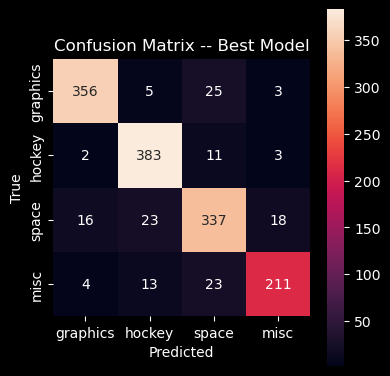

In [44]:
best_row   = max(rows, key=lambda r: r['Macro F1'])
best_name  = best_row['Model']
best_preds = best_row['_preds']
short_names = [c.split('.')[-1] for c in train.target_names]

print(f'Classification Report -- {best_name}')
print('=' * 60)
print(classification_report(test.target, best_preds, target_names=train.target_names))

cm = confusion_matrix(test.target, best_preds)
fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(cm, annot=True, square=True, fmt='d',
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix -- Best Model')
plt.tight_layout()
plt.show()

## Section 3: Per-Category Breakdown

The best classical model (highest Macro-F1 from CountVec/TF-IDF) and the best embedding model are pulled from the full results grid and compared head-to-head with per-class classification reports. This highlights whether the two representation families make *different* mistakes, which motivates exploring both rather than defaulting to one.

In [45]:
# Re-derive variables that were previously computed in the (removed) Error Analysis section
classical_rows = [r for r in rows if r['Representation'] != 'Embeddings']
embedding_rows = [r for r in rows if r['Representation'] == 'Embeddings']
best_classical = max(classical_rows, key=lambda r: r['Macro F1'])
best_embedding = max(embedding_rows, key=lambda r: r['Macro F1'])
y_true  = test.target
preds_c = best_classical['_preds']
preds_e = best_embedding['_preds']

short_names = [c.split('.')[-1] for c in train.target_names]

print('=' * 55)
print(f"Classification Report -- {best_classical['Model']}")
print('=' * 55)
print(classification_report(y_true, preds_c, target_names=short_names))

print('=' * 55)
print(f"Classification Report -- {best_embedding['Model']}")
print('=' * 55)
print(classification_report(y_true, preds_e, target_names=short_names))

Classification Report -- TF-IDF + SGD(log_loss)
              precision    recall  f1-score   support

    graphics       0.90      0.92      0.91       389
      hockey       0.97      0.92      0.95       399
       space       0.83      0.91      0.87       394
        misc       0.90      0.81      0.85       251

    accuracy                           0.90      1433
   macro avg       0.90      0.89      0.89      1433
weighted avg       0.90      0.90      0.90      1433

Classification Report -- Embeddings + LogisticReg(C=1)
              precision    recall  f1-score   support

    graphics       0.94      0.92      0.93       389
      hockey       0.90      0.96      0.93       399
       space       0.85      0.86      0.85       394
        misc       0.90      0.84      0.87       251

    accuracy                           0.90      1433
   macro avg       0.90      0.89      0.90      1433
weighted avg       0.90      0.90      0.90      1433



## Section 4: Grid Search — TF-IDF + Logistic Regression

`GridSearchCV` automates hyperparameter search by exhaustively evaluating every combination in a parameter grid using **k-fold cross-validation**. The key difference from the model grid above:

| | Model Grid | Grid Search |
|---|---|---|
| Evaluation | Single train/test split | k-fold CV on training set |
| Parameter space | Hand-crafted combinations | Cartesian product of grid |
| Overfitting risk | Higher (one test set) | Lower (averaged over k folds) |

Below we search over TF-IDF and Logistic Regression hyperparameters simultaneously with 5-fold CV scored by macro F1.

In [46]:
gs_pipe = Pipeline([
    ('vec', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

param_grid = {
    'vec__ngram_range' : [(1, 1), (1, 2)],
    'vec__max_features': [5000, 10000],
    'vec__sublinear_tf': [True, False],
    'clf__C'           : [0.1, 1.0, 10.0],
}

gs = GridSearchCV(gs_pipe, param_grid, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1)
gs.fit(train.data, train.target)

print(f'Best params:        {gs.best_params_}')
print(f'Best CV F1 (macro): {gs.best_score_:.4f}')
print()

gs_results = pd.DataFrame(gs.cv_results_)
cols = [
    'param_vec__ngram_range', 'param_vec__max_features',
    'param_vec__sublinear_tf', 'param_clf__C',
    'mean_test_score', 'std_test_score', 'rank_test_score',
]
display(gs_results[cols].sort_values('rank_test_score').head(10))

y_pred_gs = gs.best_estimator_.predict(test.data)
print('\nTest-set performance (best grid search model):')
print('=' * 60)
print(classification_report(test.target, y_pred_gs, target_names=train.target_names))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params:        {'clf__C': 10.0, 'vec__max_features': 10000, 'vec__ngram_range': (1, 1), 'vec__sublinear_tf': True}
Best CV F1 (macro): 0.8952



,param_vec__ngram_range,param_vec__max_features,param_vec__sublinear_tf,param_clf__C,mean_test_score,std_test_score,rank_test_score
20,"(1, 1)",10000,True,10.0,0.895172,0.013950,1
14,"(1, 2)",10000,True,1.0,0.894948,0.013566,2
22,"(1, 2)",10000,True,10.0,0.893765,0.013467,3
12,"(1, 1)",10000,True,1.0,0.893268,0.014983,4
23,"(1, 2)",10000,False,10.0,0.893206,0.012077,5
21,"(1, 1)",10000,False,10.0,0.892825,0.015307,6
13,"(1, 1)",10000,False,1.0,0.890395,0.014321,7
15,"(1, 2)",10000,False,1.0,0.889949,0.013265,8
8,"(1, 1)",5000,True,1.0,0.889806,0.017902,9
9,"(1, 1)",5000,False,1.0,0.889804,0.017138,10



Test-set performance (best grid search model):
                    precision    recall  f1-score   support

     comp.graphics       0.90      0.91      0.91       389
  rec.sport.hockey       0.97      0.92      0.94       399
         sci.space       0.82      0.90      0.86       394
talk.religion.misc       0.90      0.81      0.85       251

          accuracy                           0.89      1433
         macro avg       0.90      0.89      0.89      1433
      weighted avg       0.90      0.89      0.89      1433



## Section 5: Feature Importance

Three complementary ways to understand what the model has learned:

| Method | Scope | Direction | Model |
|---|---|---|---|
| RF Feature Importance | Global | Unsigned | Random Forest |
| LR Coefficients | Per-class | Signed | Logistic Regression |
| SHAP | Per-class (beeswarm summary) | Signed | Any linear model |

### Random Forest Feature Importance (Global, Unsigned)

Random Forest computes **mean decrease in impurity** (Gini impurity) across all decision trees for each feature. A high value means that word reliably reduces uncertainty when it appears as a split. Importantly, this is a *global* measure — it tells you which words the forest relied on overall, but not *which class* they point toward, nor the direction of their influence.

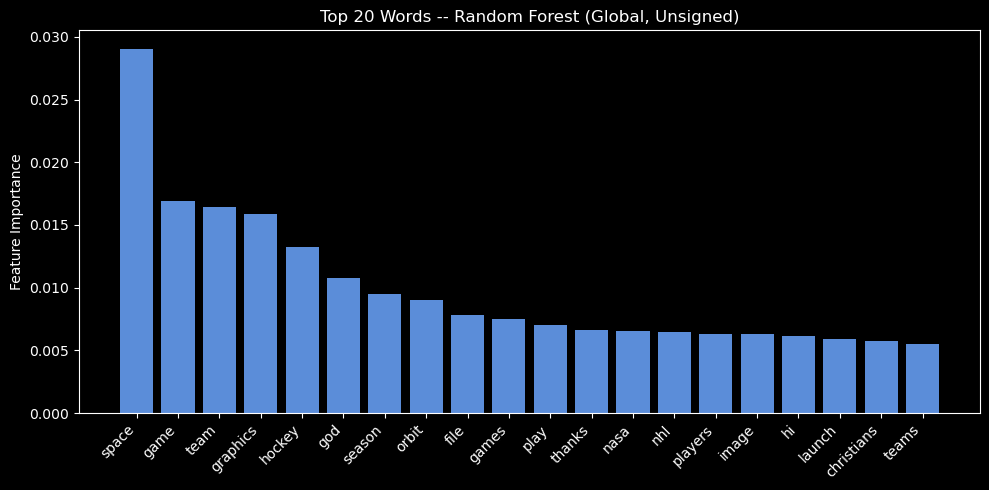

In [47]:
# Pull TF-IDF + RandomForest from the results rows
rf_row        = next(r for r in rows if r['Representation'] == 'TF-IDF'
                     and 'RandomForest' in r['Classifier'])
rf_clf        = rf_row['_clf']
feature_names = tfidf.get_feature_names_out()
importances   = rf_clf.feature_importances_

top_n   = 20
top_idx = importances.argsort()[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(top_n), importances[top_idx], color='#5b8dd9')
ax.set_xticks(range(top_n))
ax.set_xticklabels(feature_names[top_idx], rotation=45, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title(f'Top {top_n} Words -- Random Forest (Global, Unsigned)')
plt.tight_layout()
plt.show()

### Logistic Regression Coefficients (Per-Class, Signed)

In a one-vs-rest LR, each class has its own weight vector — one coefficient per vocabulary term. A large positive coefficient means the word strongly suggests membership in that class; a large negative coefficient means its presence argues against it. This is more informative than RF importance because it is both **directional** and **per-class**, making it easy to read off the defining vocabulary for each newsgroup.

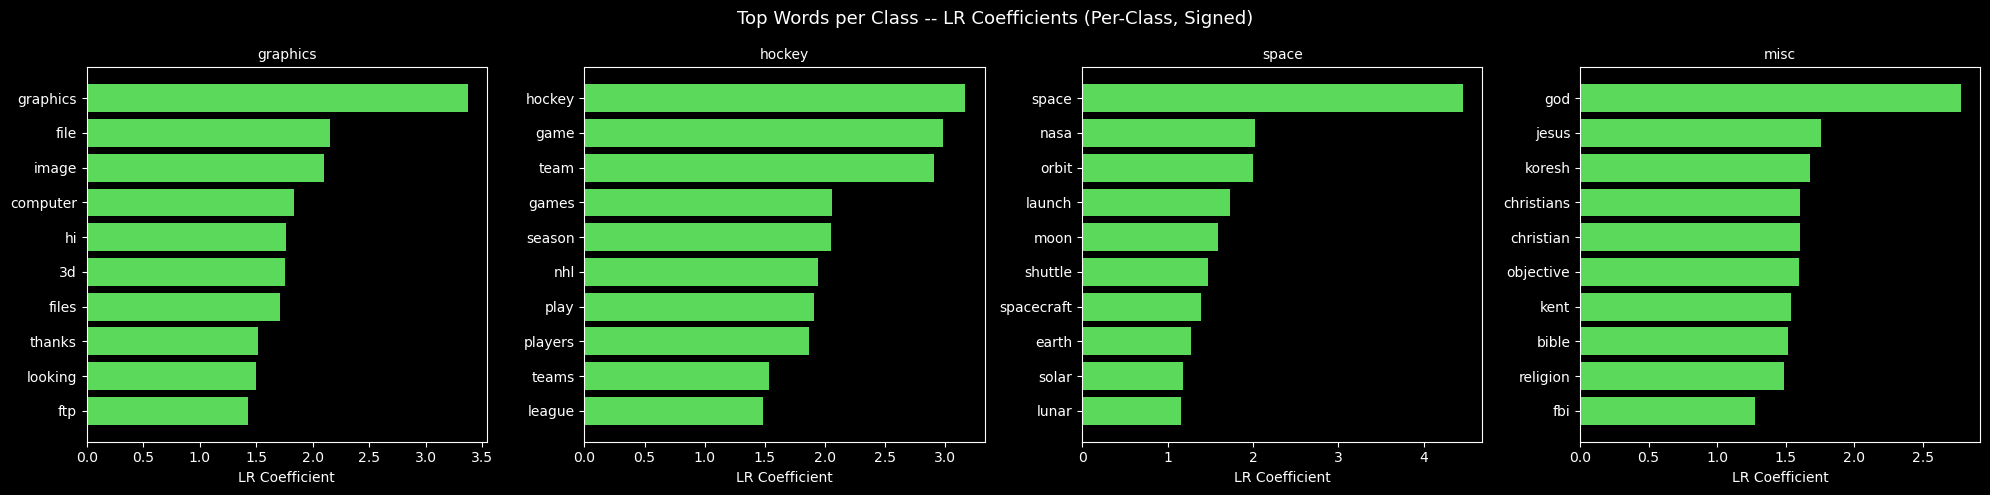

In [48]:
# Pull TF-IDF + LogisticReg from the results rows
lr_row      = next(r for r in rows if r['Representation'] == 'TF-IDF'
                   and 'LogisticReg' in r['Classifier'])
lr_clf      = lr_row['_clf']
lr_features = tfidf.get_feature_names_out()

n_cats  = len(train.target_names)
top_per = 10
fig, axes = plt.subplots(1, n_cats, figsize=(5 * n_cats, 5))

for ax, class_idx, cat in zip(axes, range(n_cats), train.target_names):
    coefs   = lr_clf.coef_[class_idx]
    top_pos = coefs.argsort()[::-1][:top_per]
    words   = lr_features[top_pos]
    scores  = coefs[top_pos]
    ax.barh(list(words)[::-1], list(scores)[::-1], color='#5bd95b')
    ax.set_title(cat.split('.')[-1], fontsize=10)
    ax.set_xlabel('LR Coefficient')

plt.suptitle('Top Words per Class -- LR Coefficients (Per-Class, Signed)', fontsize=13)
plt.tight_layout()
plt.show()

### SHAP — SHapley Additive exPlanations (Beeswarm Summary)

SHAP assigns each word a **signed credit score** for a specific prediction: a positive value pushes the model toward the predicted class, a negative value pushes away. These are computed per-document via `LinearExplainer` (exact for linear models) and then aggregated across all test documents to produce the **dot/beeswarm summary**.

Reading the beeswarm plot per class:
- Each dot = one document × one feature; x-axis = SHAP value; **color** = TF-IDF value (red = high, blue = low/absent).
- **Rightmost red dots**: high TF-IDF weight *and* pushes toward this class → defining vocabulary.
- **Leftmost blue dots**: word absent/low-weight *and* that actively argues *against* this class.
- Features are ranked by mean |SHAP| — highest-impact words appear at the top.

We fit a dedicated LR on `tfidf_shap` (5000 features instead of 10000) to keep the dense background matrix manageable (~43 MB vs. ~172 MB).

In [49]:
# Fit a dedicated LR on tfidf_shap features for SHAP attribution
lr_explain_shap = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr_explain_shap.fit(X_train_tfidf_shap, train.target)
shap_features = tfidf_shap.get_feature_names_out()

# LinearExplainer requires dense arrays; limit to 200 test docs to keep memory manageable
X_train_shap_dense = X_train_tfidf_shap.toarray()
X_test_shap_dense  = X_test_tfidf_shap[:200].toarray()

explainer   = shap.LinearExplainer(lr_explain_shap, X_train_shap_dense)
shap_values = explainer.shap_values(X_test_shap_dense)

# Modern SHAP returns one (n_samples, n_features, n_classes) array; older SHAP returned
# a list of (n_samples, n_features) arrays per class. Normalize to the per-class list
# so the plots below work on either SHAP version.
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, c] for c in range(shap_values.shape[2])]

print(f'Classes:              {len(shap_values)}')
print(f'SHAP shape per class: {shap_values[0].shape}')
print('One array per class — rows = documents, columns = vocabulary features.')

Background dataset has 2154 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2154 when initializing the masker.


Classes:              4
SHAP shape per class: (200, 5000)
One array per class — rows = documents, columns = vocabulary features.


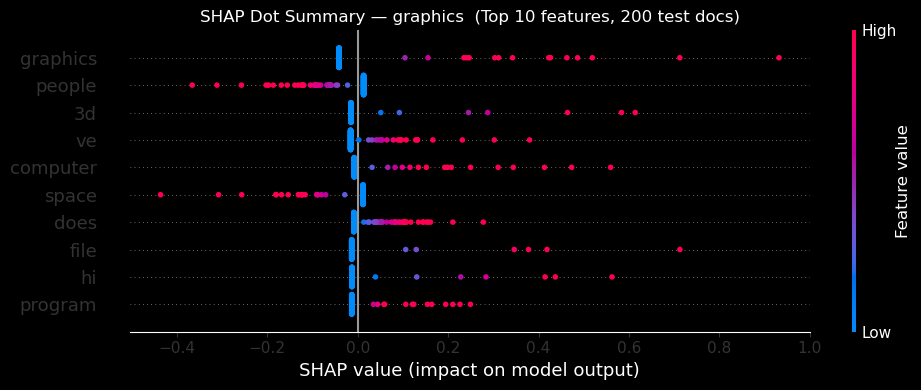

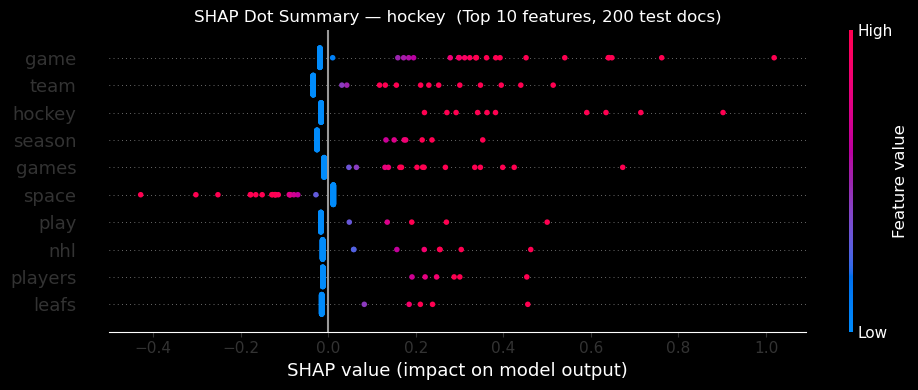

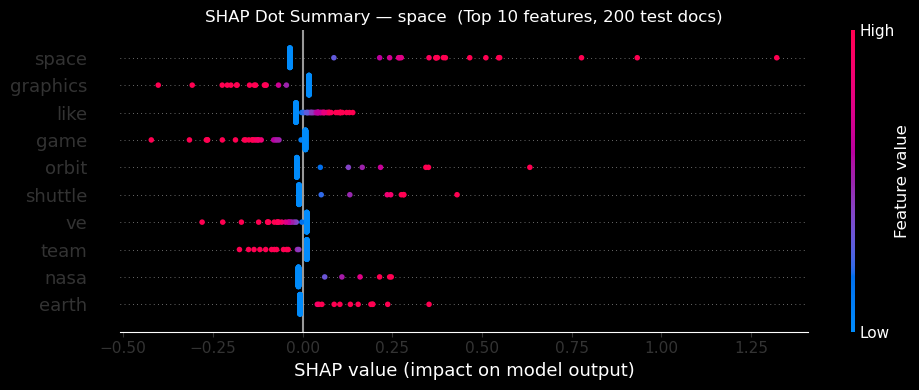

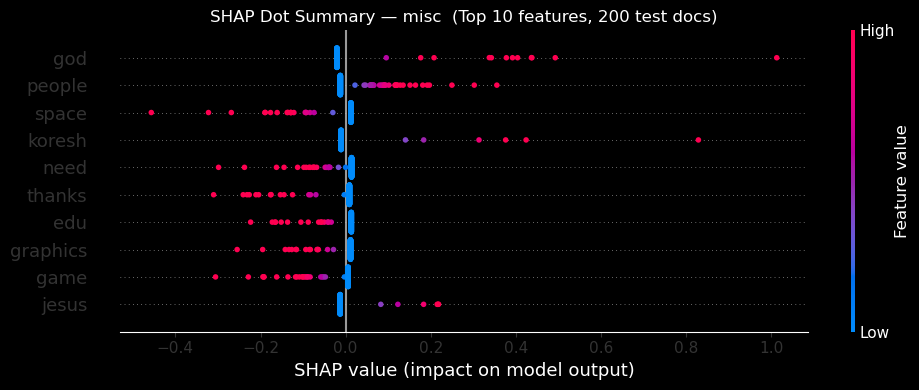

In [50]:
for i, cat in enumerate(train.target_names):
    shap.summary_plot(
        shap_values[i], X_test_shap_dense,
        feature_names=shap_features,
        plot_type='dot', max_display=10,
        show=False, plot_size=(10, 4),
    )
    plt.title(f'SHAP Dot Summary — {cat.split(".")[-1]}  (Top 10 features, 200 test docs)')
    plt.tight_layout()
    plt.show()

## Conclusion -- When to Use What

| Factor | Classical (CountVec/TF-IDF) | Semantic (Embeddings) |
|---|---|---|
| **Accuracy** | Good | Often better |
| **Speed** | Fast | Slower (inference) |
| **Interpretability** | High -- features are words | Low -- features are latent dims |
| **Data size** | Works well with small corpora | Shines on small datasets (pre-trained) |
| **Domain transfer** | Weak -- vocab must match | Strong -- pre-trained on broad text |
| **Memory** | Sparse (efficient) | Dense (larger) |

### Practical rules of thumb

- **Start with TF-IDF + Logistic Regression.** It's fast, interpretable, and surprisingly strong.
- **Use SHAP or LR coefficients** to understand what the classical model learned.
- **Upgrade to embeddings** when you need better generalization, have short texts, or the vocabulary varies a lot between train and test.
- **Don't use Random Forest on text** unless you have a specific reason -- it's slow and rarely beats LR on sparse features.

## Feature Importance: Method Comparison

| | RF Feature Importance | LR Coefficients | SHAP |
|---|---|---|---|
| Scope | Global (whole dataset) | Per-class | Per-class (aggregated from per-doc values) |
| Direction | No sign (always positive) | Signed | Signed |
| Model | Random Forest | Logistic Regression | Any linear model |
| Best for | Overall word importance | Which words define each class | Which words drive predictions *and* how feature value relates to impact |

**Next ->** Notebook 4 applies these techniques to real-world text corpora.